In [1]:
import pandas as pd

In [2]:
df= pd.read_csv('aapl_us_2025.csv')

In [3]:
df.head()

,Date,Open,High,Low,Close,Volume
0,1984-09-07,0.099824,0.101049,0.098619,0.099824,9.859472e+07
1,1984-09-10,0.099824,0.100130,0.097424,0.099232,7.652559e+07
2,1984-09-11,0.100130,0.102846,0.100130,0.101049,1.804519e+08
3,1984-09-12,0.101049,0.101641,0.098007,0.098007,1.576401e+08
4,1984-09-13,0.103460,0.103754,0.103460,0.103460,2.455186e+08


In [4]:
df.dtypes

Date       object
Open      float64
High      float64
Low       float64
Close     float64
Volume    float64
dtype: object

In [5]:
df.describe()

,Open,High,Low,Close,Volume
count,10171.000000,10171.000000,10171.000000,10171.000000,1.017100e+04
mean,25.899876,26.174829,25.637547,25.918857,3.907497e+08
std,51.852504,52.391692,51.349332,51.900034,4.059731e+08
min,0.054895,0.055497,0.054292,0.054292,2.838200e+06
25%,0.290365,0.297102,0.284705,0.290206,1.371105e+08
50%,0.951622,0.970583,0.922582,0.948656,2.573887e+08
75%,22.188000,22.403300,21.935650,22.172700,4.950640e+08
max,258.190000,260.100000,257.630000,259.020000,8.788463e+09


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df= df.sort_values(by= 'Date')

In [8]:
df.tail()

,Date,Open,High,Low,Close,Volume
10166,2025-01-13,233.530,234.67,229.720,234.40,49630725.0
10167,2025-01-14,234.750,236.12,232.472,233.28,39435294.0
10168,2025-01-15,234.635,238.96,234.430,237.87,39831969.0
10169,2025-01-16,237.350,238.01,228.030,228.26,71759052.0
10170,2025-01-17,232.115,232.29,228.480,229.98,68488301.0


In [9]:
duplicates= df.duplicated().sum()

In [10]:
df.isna().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [11]:
df.dtypes

Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume           float64
dtype: object

In [12]:
df= df.set_index('Date')

In [13]:
df= df.sort_index()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10171 entries, 1984-09-07 to 2025-01-17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    10171 non-null  float64
 1   High    10171 non-null  float64
 2   Low     10171 non-null  float64
 3   Close   10171 non-null  float64
 4   Volume  10171 non-null  float64
dtypes: float64(5)
memory usage: 476.8 KB


In [15]:
Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

original_shape = df.shape
df = df[(df['Close'] >= lower_bound) & (df['Close'] <= upper_bound)]
new_shape = df.shape

print(f"rows reduced from {original_shape[0]} to {new_shape[0]}.")

rows reduced from 10171 to 8845.


In [16]:
import matplotlib.pyplot as plt

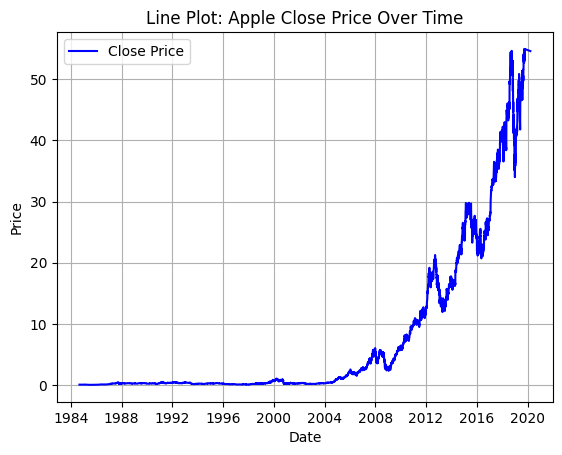

In [17]:
plt.plot(df['Close'], label='Close Price', color='blue')
plt.title('Line Plot: Apple Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.legend()
plt.show()

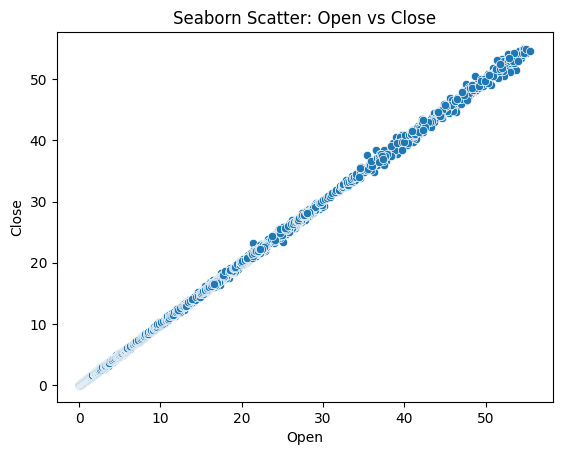

In [18]:
import seaborn as sns
sns.scatterplot(data=df, x='Open', y='Close')
plt.title('Seaborn Scatter: Open vs Close')
plt.show()

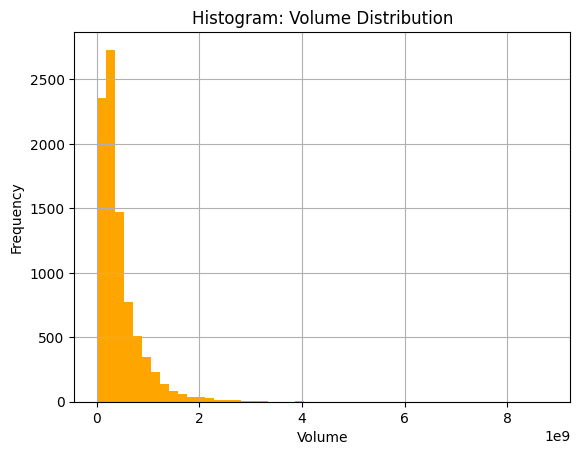

In [22]:
plt.hist(df['Volume'], bins=50, color='orange')
plt.title('Histogram: Volume Distribution')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

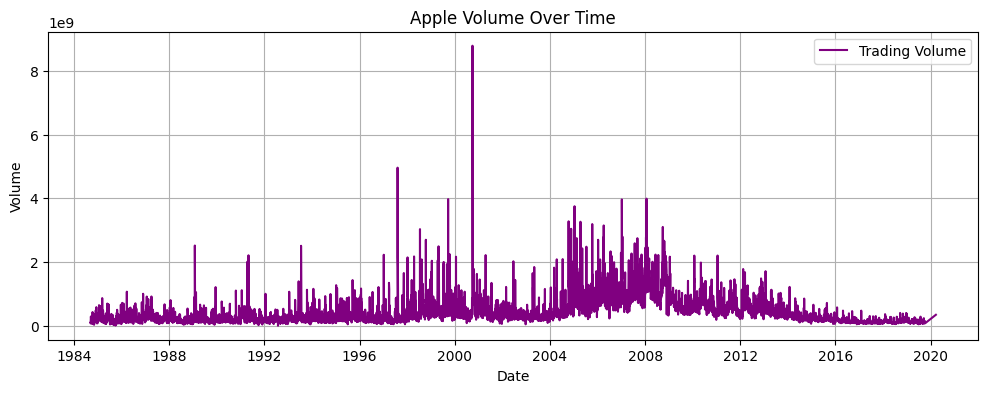

In [24]:
plt.figure(figsize=(12, 4))
plt.plot(df['Volume'], label='Trading Volume', color='purple')
plt.title('Apple Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
test_size = 365
train = df.iloc[:-test_size]
test = df.iloc[-test_size:]
print(train.shape)

(8480, 5)


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8845 entries, 1984-09-07 to 2020-03-23
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    8845 non-null   float64
 1   High    8845 non-null   float64
 2   Low     8845 non-null   float64
 3   Close   8845 non-null   float64
 4   Volume  8845 non-null   float64
dtypes: float64(5)
memory usage: 414.6 KB


In [27]:
print(df.columns)

Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8845 entries, 1984-09-07 to 2020-03-23
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    8845 non-null   float64
 1   High    8845 non-null   float64
 2   Low     8845 non-null   float64
 3   Close   8845 non-null   float64
 4   Volume  8845 non-null   float64
dtypes: float64(5)
memory usage: 414.6 KB


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8845 entries, 1984-09-07 to 2020-03-23
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    8845 non-null   float64
 1   High    8845 non-null   float64
 2   Low     8845 non-null   float64
 3   Close   8845 non-null   float64
 4   Volume  8845 non-null   float64
dtypes: float64(5)
memory usage: 414.6 KB


In [30]:
from statsmodels.tsa.stattools import adfuller

In [31]:
result= adfuller(train['Close'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
for key, value in result[4].items():
    print(f'Critical Value ({key}): {value}')
if result[1] < 0.05:
    print("The series is stationary")
else:
    print("The series is non-stationary")

ADF Statistic: 3.088011691844044
p-value: 1.0
Critical Value (1%): -3.431124850687746
Critical Value (5%): -2.8618824309525883
Critical Value (10%): -2.5669522711136055
The series is non-stationary


In [32]:
df_diff = train['Close'].diff().dropna()

result_diff = adfuller(df_diff)
print('ADF Statistic (after differencing):', result_diff[0])
print('p-value:', result_diff[1])

ADF Statistic (after differencing): -15.09322632090292
p-value: 8.136583920230886e-28


c:\Users\HP\.conda\envs\tf-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\.conda\envs\tf-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\.conda\envs\tf-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\.conda\envs\tf-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return ge

Evaluation on last 30 actual days:
 RMSE: 8.40
 MAE: 6.84
 MAPE: 2.77%
 R² Score: -0.1650


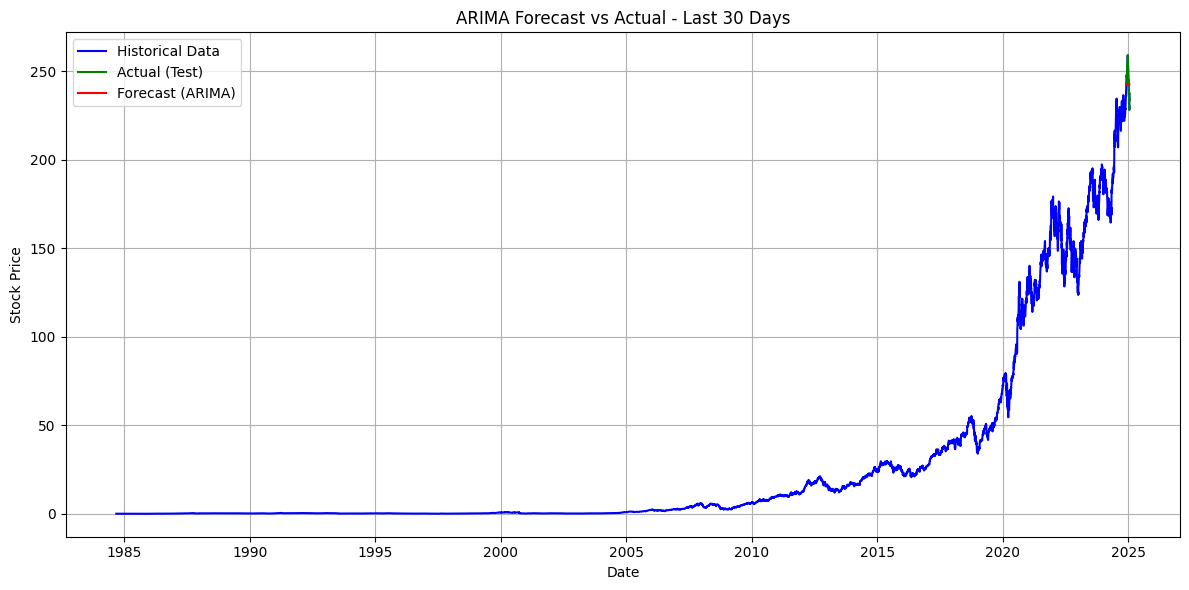

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


data = pd.read_csv('aapl_us_2025.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)


train_data = data['Close'][:-30]
test_data = data['Close'][-30:]


ar_model = ARIMA(train_data, order=(5, 1, 0))
ar_model_fit = ar_model.fit()

forecast = ar_model_fit.forecast(steps=30)

actual_ar = test_data.values
pred_ar = forecast.values

rmse_ar = np.sqrt(mean_squared_error(actual_ar, pred_ar))
mae_ar = mean_absolute_error(actual_ar, pred_ar)
mape_ar = np.mean(np.abs((actual_ar - pred_ar) / actual_ar)) * 100
r2_ar = r2_score(actual_ar, pred_ar)

print("Evaluation on last 30 actual days:")
print(f" RMSE: {rmse_ar:.2f}")
print(f" MAE: {mae_ar:.2f}")
print(f" MAPE: {mape_ar:.2f}%")
print(f" R² Score: {r2_ar:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Historical Data', color='blue')
plt.plot(test_data.index, actual_ar, label='Actual (Test)', color='green')
plt.plot(test_data.index, pred_ar, label='Forecast (ARIMA)', color='red')
plt.title('ARIMA Forecast vs Actual - Last 30 Days')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


c:\Users\HP\.conda\envs\tf-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\.conda\envs\tf-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\.conda\envs\tf-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\.conda\envs\tf-env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an excepti

RMSE: 16.94
MAE: 15.23
MAPE: 6.11%
R² Score: -3.7300


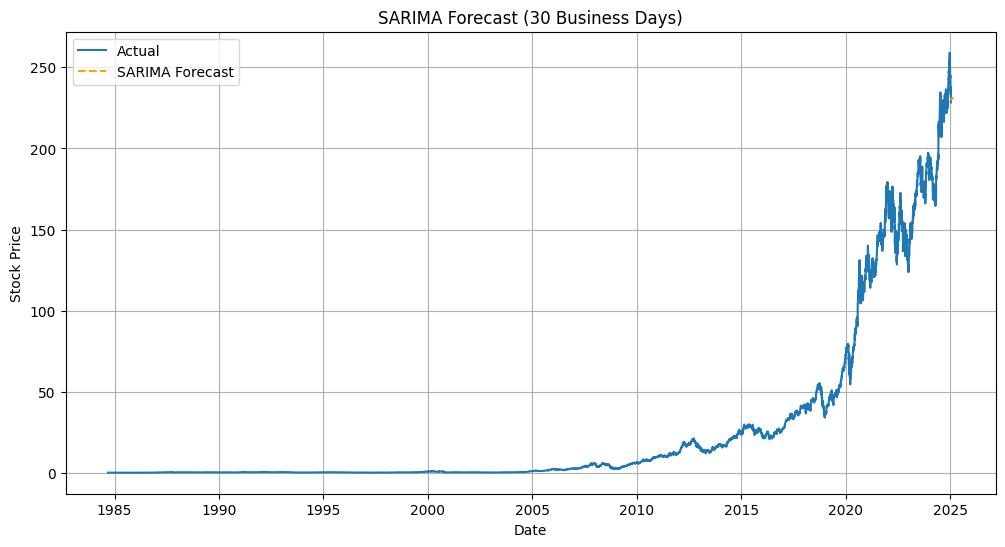

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX


df = pd.read_csv("aapl_us_2025.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df = df[['Close']].dropna()

sr_model = SARIMAX(
    df['Close'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 5), 
    enforce_stationarity=False,
    enforce_invertibility=False
)

sr_model_fit = sr_model.fit()

forecast = sr_model_fit.forecast(steps=30)

last_date = df.index[-1]
forecast_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='B')
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

actual_sr = df['Close'][-30:].values
pred_sr = forecast.values

rmse_sr = np.sqrt(mean_squared_error(actual_sr, pred_sr))
mae_sr = mean_absolute_error(actual_sr, pred_sr)
mape_sr = np.mean(np.abs((actual_sr - pred_sr) / actual_sr)) * 100
r2_sr = r2_score(actual_sr, pred_sr)

print(f"RMSE: {rmse_sr:.2f}")
print(f"MAE: {mae_sr:.2f}")
print(f"MAPE: {mape_sr:.2f}%")
print(f"R² Score: {r2_sr:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Actual')
plt.plot(forecast_index, forecast, label='SARIMA Forecast', color='orange', linestyle='--')
plt.title('SARIMA Forecast (30 Business Days)')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid()
plt.show()



In [ ]:
pip install keras

Note: you may need to restart the kernel to use updated packages.


c:\Users\HP\.conda\envs\tf-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
17:29:42 - cmdstanpy - INFO - Chain [1] start processing
17:29:56 - cmdstanpy - INFO - Chain [1] done processing


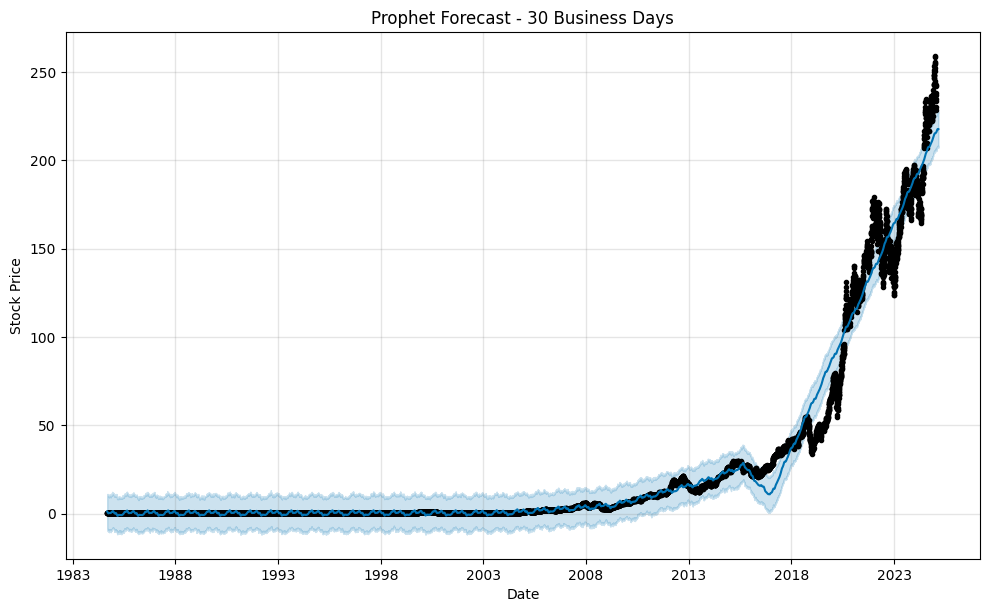

RMSE: 7.69
MAE: 3.74
MAPE: 165.23%
R² Score: 0.9780


In [36]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('aapl_us_2025.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df[['Date', 'Close']].dropna()

df = df.rename(columns={'Date': 'ds', 'Close': 'y'})

pr_model = Prophet(daily_seasonality=True)
pr_model.fit(df)

future = pr_model.make_future_dataframe(periods=30, freq='B')
forecast = pr_model.predict(future)

fig1 = pr_model.plot(forecast)
plt.title('Prophet Forecast - 30 Business Days')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.grid(True)
plt.show()

merged = pd.merge(df, forecast[['ds', 'yhat']], on='ds', how='inner')
actual_pr = merged['y'].values
pred_pr = merged['yhat'].values

rmse_pr = np.sqrt(mean_squared_error(actual_pr, pred_pr))
mae_pr = mean_absolute_error(actual_pr, pred_pr)
mape_pr = np.mean(np.abs((actual_pr - pred_pr) / actual_pr)) * 100
r2_pr = r2_score(actual_pr, pred_pr)

print(f"RMSE: {rmse_pr:.2f}")
print(f"MAE: {mae_pr:.2f}")
print(f"MAPE: {mape_pr:.2f}%")
print(f"R² Score: {r2_pr:.4f}")


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10171 entries, 1984-09-07 to 2025-01-17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    10171 non-null  float64
 1   High    10171 non-null  float64
 2   Low     10171 non-null  float64
 3   Close   10171 non-null  float64
 4   Volume  10171 non-null  float64
dtypes: float64(5)
memory usage: 476.8 KB


c:\Users\HP\.conda\envs\tf-env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
253/253 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - loss: 9.3796e-05 - val_loss: 6.2348e-04
Epoch 2/5
253/253 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 3.3091e-06 - val_loss: 0.0019
Epoch 3/5
253/253 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - loss: 2.3905e-06 - val_loss: 0.0016
Epoch 4/5
253/253 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - loss: 2.4290e-06 - val_loss: 0.0013
Epoch 5/5
253/253 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - loss: 1.7702e-06 - val_loss: 0.0014


 Model saved as lstm_stock_model.h5
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


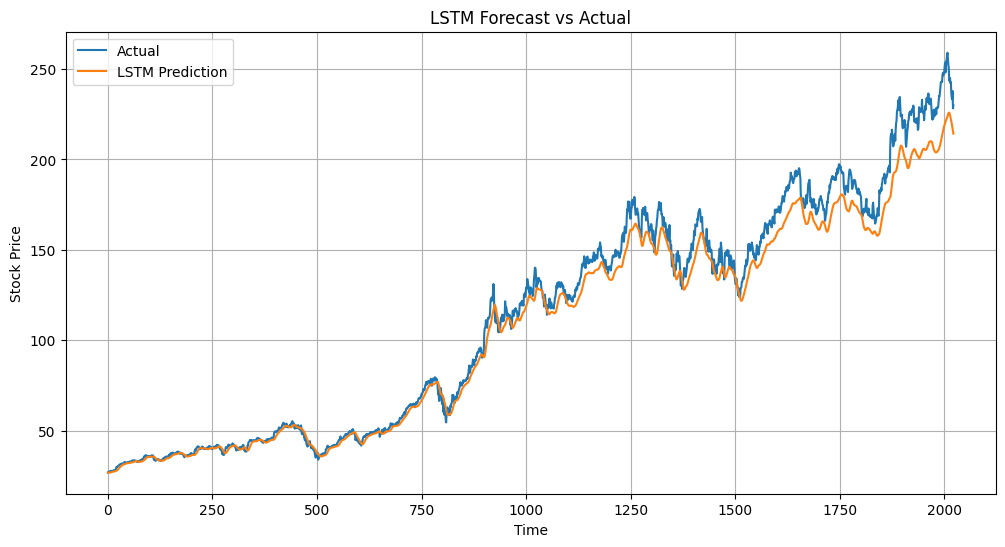

RMSE: 9.81
MAE: 6.77
MAPE: 4.87%
R² Score: 0.9759
[[212.84967 ]
 [210.66891 ]
 [207.99811 ]
 [205.04327 ]
 [201.94926 ]
 [198.81413 ]
 [195.70123 ]
 [192.64944 ]
 [189.68129 ]
 [186.80818 ]
 [184.03482 ]
 [181.36156 ]
 [178.78632 ]
 [176.30574 ]
 [173.91574 ]
 [171.61201 ]
 [169.39032 ]
 [167.24632 ]
 [165.1761  ]
 [163.17569 ]
 [161.24156 ]
 [159.37027 ]
 [157.55858 ]
 [155.80347 ]
 [154.10207 ]
 [152.45172 ]
 [150.84991 ]
 [149.29433 ]
 [147.78271 ]
 [146.31302 ]
 [144.88332 ]
 [143.49173 ]
 [142.13657 ]
 [140.81627 ]
 [139.52934 ]
 [138.27434 ]
 [137.04988 ]
 [135.85481 ]
 [134.6879  ]
 [133.54799 ]
 [132.43411 ]
 [131.34525 ]
 [130.28044 ]
 [129.23882 ]
 [128.21953 ]
 [127.22182 ]
 [126.244835]
 [125.28795 ]
 [124.35047 ]
 [123.431694]
 [122.53105 ]
 [121.64794 ]
 [120.78176 ]
 [119.93201 ]
 [119.09814 ]
 [118.27972 ]
 [117.47623 ]
 [116.68723 ]
 [115.91227 ]
 [115.15098 ]]


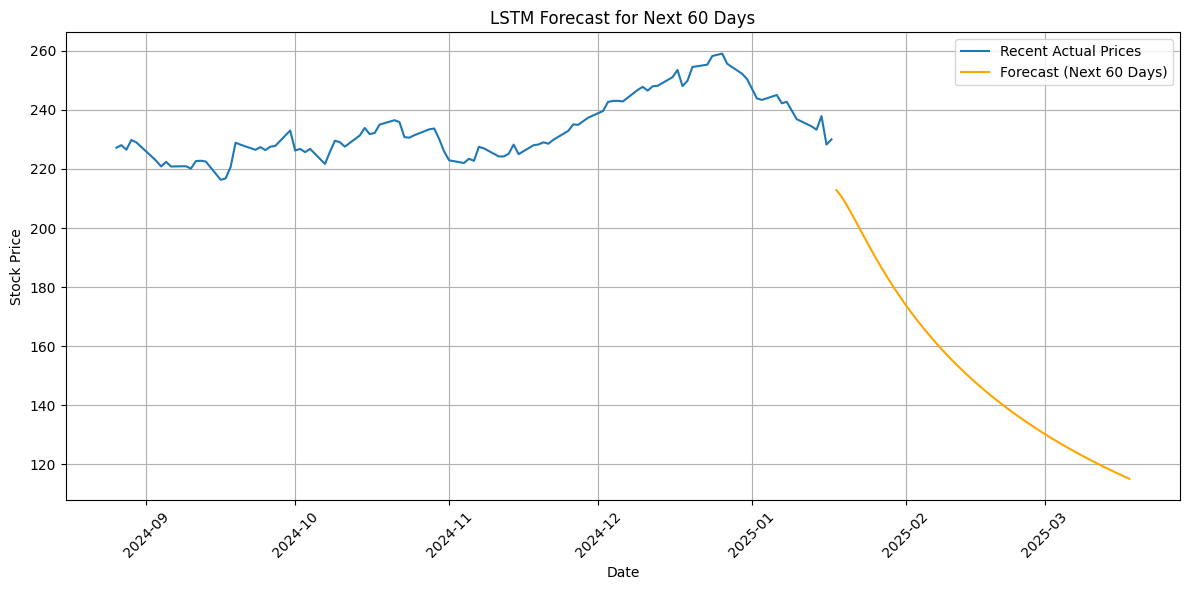

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

df = pd.read_csv('aapl_us_2025.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

data = df[['Close']].values

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 60
X, y = create_sequences(scaled_data, window_size)

X = X.reshape((X.shape[0], X.shape[1], 1))

split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

ls_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(window_size, 1)),
    LSTM(50),
    Dense(1)
])
ls_model.compile(optimizer='adam', loss='mse')
ls_model.summary()

history = ls_model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test), verbose=1)

ls_model.save("lstm_stock_model.h5")
print(" Model saved as lstm_stock_model.h5")
ls_model.compile(optimizer='adam', loss='mse')

pred_scaled = ls_model.predict(X_test)
predicted = scaler.inverse_transform(pred_scaled.reshape(-1, 1))
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(12, 6))
plt.plot(actual, label='Actual')
plt.plot(predicted, label='LSTM Prediction')
plt.title('LSTM Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.grid()
plt.show()

rmse_lstm = np.sqrt(mean_squared_error(actual, predicted))
mae_lstm = mean_absolute_error(actual, predicted)
mape_lstm = np.mean(np.abs((actual - predicted) / actual)) * 100
r2_lstm = r2_score(actual, predicted)

print(f"RMSE: {rmse_lstm:.2f}")
print(f"MAE: {mae_lstm:.2f}")
print(f"MAPE: {mape_lstm:.2f}%")
print(f"R² Score: {r2_lstm:.4f}")

from tensorflow.keras.models import load_model

n_days = 60

model = load_model("lstm_stock_model.h5", compile=False)
last_60 = scaled_data[-60:]
input_seq = last_60.reshape(1, 60, 1)

future_predictions_scaled = []

for _ in range(n_days):
    next_pred = model.predict(input_seq, verbose=0)[0][0]
    future_predictions_scaled.append(next_pred)
    
 
    next_input = np.append(input_seq[0, 1:], [[next_pred]], axis=0)
    input_seq = next_input.reshape(1, 60, 1)


future_predictions = scaler.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))
print(future_predictions)
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=n_days)

plt.figure(figsize=(12, 6))
plt.plot(df.index[-100:], df['Close'].values[-100:], label='Recent Actual Prices')
plt.plot(future_dates, future_predictions, label=f'Forecast (Next {n_days} Days)', color='orange')
plt.title(f"LSTM Forecast for Next {n_days} Days")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()